# Heisenberg chain のハミルトニアンシミュレーション回路資源比較

Open XXX Heisenberg chain に対する Trotter–Suzuki、QSVT、multiproduct formula (MPF) を、同じ Pauli 和と誤差予算の下で比較します。小規模系では実際の statevector、大規模系では密行列を作らないゲート分解モデルを使います。

In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
from dataclasses import asdict

import numpy as np
import pandas as pd

from hamiltonian_resources import (
    BenchmarkConfig, HamiltonianSpec, MultiproductMethod, QSVTMethod,
    TimeScaling, TrotterMethod, build_simulation_circuit,
    compare_plan_with_exact, estimate_resources, plot_benchmark,
    run_benchmark, heisenberg_chain,
)
pd.set_option("display.max_columns", None)

## 0 グローバルに使うベンチマーク設定

In [ ]:
SYSTEM_SIZES = np.geomspace(5, 100, num=11, dtype=np.int_)
TARGET_ERRORS = np.logspace(-1, -12, 12)
TIME_PER_QUBIT = 1.0
FIXED_SYSTEM_SIZE = 50
FIXED_TARGET_ERROR = 1e-3

## 1. ハミルトニアン入力

例として open XXX Heisenberg chain $H=J\sum_i(X_iX_{i+1}+Y_iY_{i+1}+Z_iZ_{i+1})+h_z\sum_iZ_i$ を使います。Qiskit の Pauli label は右端が qubit 0 です。任意の Pauli 和は `PauliHamiltonian.from_terms` で渡せます。

In [21]:
H = heisenberg_chain(3, coupling=1.0, field_z=0.7)
print(H.name, H.terms)
print(f"terms={H.term_count}, alpha=sum|h_j|={H.alpha:.3f}")

Heisenberg-3 (('IXX', 1.0), ('IYY', 1.0), ('IZZ', 1.0), ('XXI', 1.0), ('YYI', 1.0), ('ZZI', 1.0), ('IIZ', 0.7), ('IZI', 0.7), ('ZII', 0.7))
terms=9, alpha=sum|h_j|=8.100


## 2. 単一点resource評価とalgorithm plan

`estimate_resources`はHamiltonian・手法・時刻・目標誤差からparameterを1回だけ選択し、backend非依存のimmutable planと構造化解析resource結果を返します。`error_analysis`では、parameter選択用の`sizing_estimate`、scopeを明示した数学的`claims`、state依存の`observations`を分離します。

次のMPF例は、ideal MPFの目標がcertifiedでも、実装するrepeated shared-ancilla good blockの保守的な上界は同じ目標を満たさない場合を示します。resource見積りは後者の実回路構成に対応します。論理演算数は`report.plan.logical_counts`が正本で、T/CNOT、temporary-AND、backend work qubitは`report.resources`とprovenance側に属します。

In [22]:
point_report = estimate_resources(
    H,
    MultiproductMethod(2),
    time=0.2,
    target_error=1e-3,
)

analysis = point_report.error_analysis

display(pd.Series({
    "selected_parameters": point_report.selected_parameters,
    "error_budget": {
        "algorithm": point_report.error_budget.algorithm_error,
        "synthesis": point_report.error_budget.synthesis_error,
    },
    "parameter_selection_succeeded": point_report.parameter_selection_succeeded,
    "ideal_algorithm_target": analysis.ideal_algorithm_target.outcome,
    "ideal_algorithm_target_certified": point_report.ideal_algorithm_target_certified,
    "implemented_circuit_target": analysis.implemented_circuit_target.outcome,
    "implemented_circuit_target_certified": point_report.implemented_circuit_target_certified,
    "logical_counts": point_report.logical_counts.as_dict(),
    "analytical_resources": point_report.resources.as_dict(),
    "analytical_provenance": point_report.resource_provenance.as_dict(),
}, name="single-point report"))

display(pd.Series(asdict(analysis.sizing_estimate), name="parameter-selection estimate"))
display(pd.DataFrame([
    {"method": supported.method, **asdict(supported.claim)}
    for supported in analysis.claims
]))

selected_parameters                     {'mpf_m': 2, 'mpf_segments': 5, 'mpf_schedule'...
error_budget                            {'algorithm': 0.0009000000000000001, 'synthesi...
parameter_selection_succeeded                                                        True
ideal_algorithm_target                                                          certified
ideal_algorithm_target_certified                                                     True
implemented_circuit_target                                                        not_met
implemented_circuit_target_certified                                                False
logical_counts                          {'totals': {'prepare': 30, 'select': 15, 'good...
analytical_resources                    {'algorithm': 'multiproduct', 'num_qubits': 6,...
analytical_provenance                   {'backend': 'analytical', 'model': 'structured...
Name: single-point report, dtype: object

value                                                0.000686
method                              low2019-l1-ideal-rigorous
category                                           analytical
certification                                        rigorous
quantity               evolution-operator approximation error
metric                                        operator-2-norm
scope                                               ideal-mpf
target                                                 0.0009
segments                                                    5
term_count                                                  2
schedule                                                  new
exponents                                              (1, 2)
coefficient_l1_norm                                  1.666667
Name: parameter-selection estimate, dtype: object

,method,value,category,certification,quantity,metric,scope
0,low2019-l1-ideal-rigorous,0.000686,analytical,rigorous,evolution-operator approximation error,operator-2-norm,ideal-mpf
1,low2019-l1-ideal-rigorous-local-step,0.000137,analytical,rigorous,one-segment evolution-operator approximation e...,operator-2-norm,one-segment-ideal-mpf
2,exact-cubic-oaa-unitarity-defect,0.000274,derived,rigorous,amplified good-block approximation error,operator-2-norm,one-segment-amplified-good-block
3,gslw2019-reused-ancilla-product,0.027429,derived,rigorous,repeated projected good-block approximation error,operator-2-norm,repeated-shared-ancilla-good-block


同じplanをreference Qiskit backendと小規模な厳密検証へ渡せます。`compare_plan_with_exact`のstate error、fidelity、success probabilityは、指定した初期状態とpostselection規約を持つ`MetricObservation`であり、operator-norm certificateではありません。Qiskit回路と構造化解析backendは同じ論理構造を消費しますが、MPF/QSVTのgeneric `.control()` と効率的な構造化compileなど、異なるcompile仮定は別々のprovenanceとして記録されます。

In [23]:
point_circuit = build_simulation_circuit(point_report.plan)
point_validation = compare_plan_with_exact(point_report.plan)
point_report = point_report.with_observations(point_validation.observations)

display(pd.Series({
    "reference_circuit_qubits": point_circuit.num_qubits,
    "qiskit_provenance": point_circuit.metadata["resource_provenance"],
    **point_validation,
}, name="same-plan reference validation"))

display(pd.DataFrame([
    {
        "quantity": observation.quantity,
        "value": observation.value,
        "metric": observation.metric,
        "scope": observation.scope,
        "context": asdict(observation.context),
    }
    for observation in point_report.error_analysis.observations
]))

reference_circuit_qubits                                                    5
qiskit_provenance           {'backend': 'qiskit-reference', 'model': 'qisk...
method                                                           multiproduct
state_error                                                               0.0
fidelity                                                                  1.0
success_probability                                                       1.0
Name: same-plan reference validation, dtype: object

,quantity,value,metric,scope,context
0,state-error,7.212324e-15,phase-aligned-state-2-norm,normalized-postselected-system-state,{'initial_state': {'source': 'computational-ze...
1,fidelity,1.000000e+00,pure-state-fidelity,normalized-postselected-system-state,{'initial_state': {'source': 'computational-ze...
2,success-probability,1.000000e+00,good-subspace-probability,raw-circuit-output,{'initial_state': {'source': 'computational-ze...


## 3. notebook内でbenchmarkを実行して可視化

上の設定から両方のsweepをメモリ上で計算します。各rowは上と同じ単一点planning/evaluation pathを使い、parameter選択を繰り返しません。ファイルは自動生成されません。system-sizeとresourceの軸はlog10です。各モデルでは、全次数を示す詳細版と、各点でT countが最小になるTrotter/MPF次数を選ぶ簡易版を分けて作ります。簡易版のCNOT countもT countで選んだ同じ構成を使い、選択次数は各点の横に表示します。

data schema、target-error sweep、best-of-family summary、解析上の仮定は`docs/resource_scaling_benchmarks.md`を参照してください。

### Transversal Field Ising Model (TFIM) の比較

#### 詳細版（全次数）

benchmark: 100%|██████████| 288/288 [02:13<00:00,  2.16it/s, target-error n=50 eps=1e-12 qsvt ok]                       


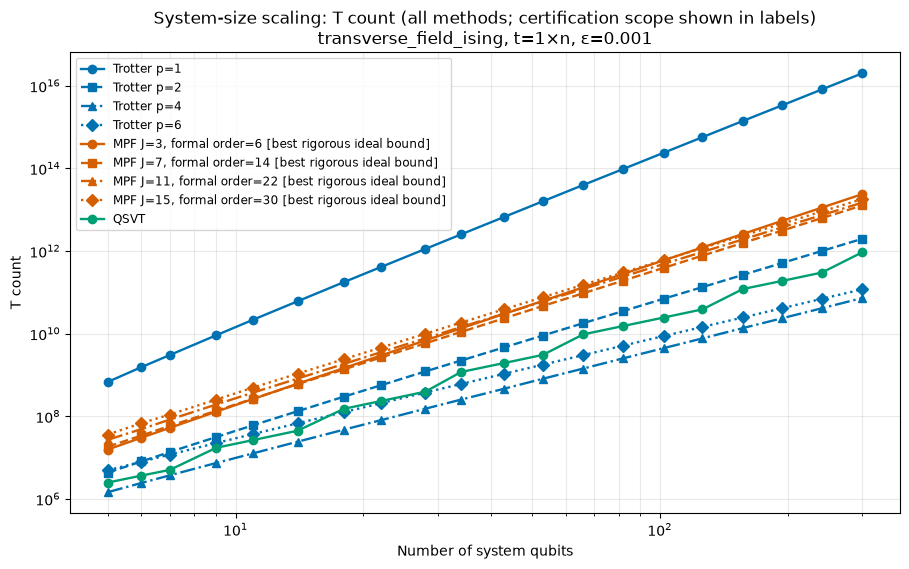

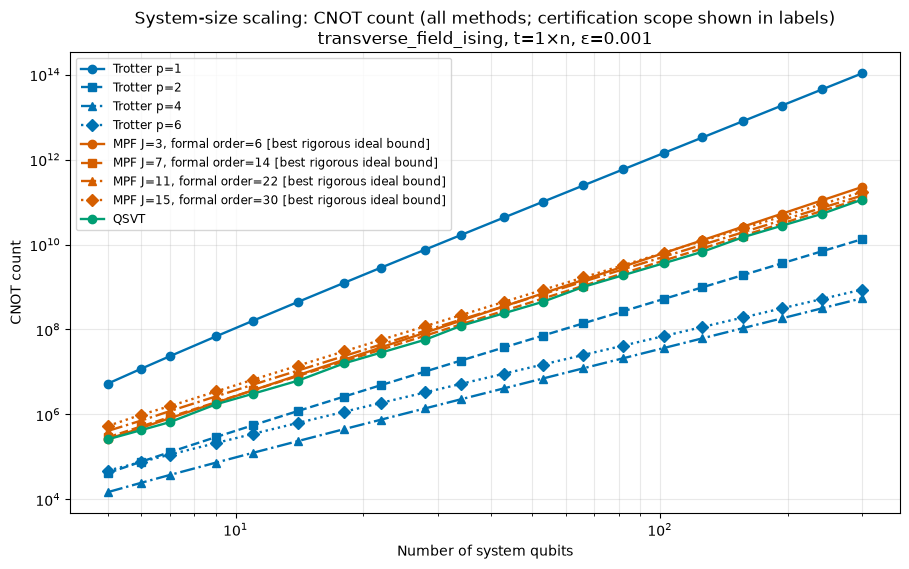

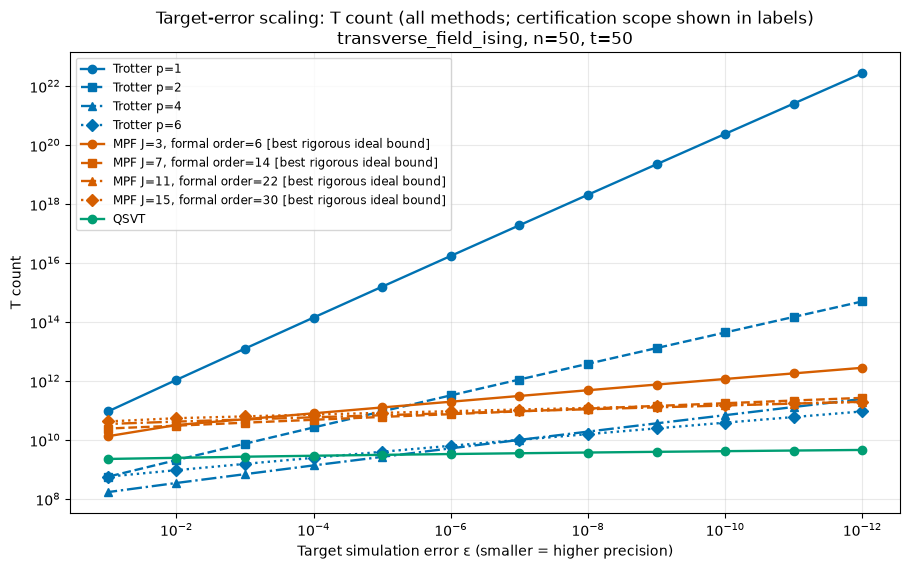

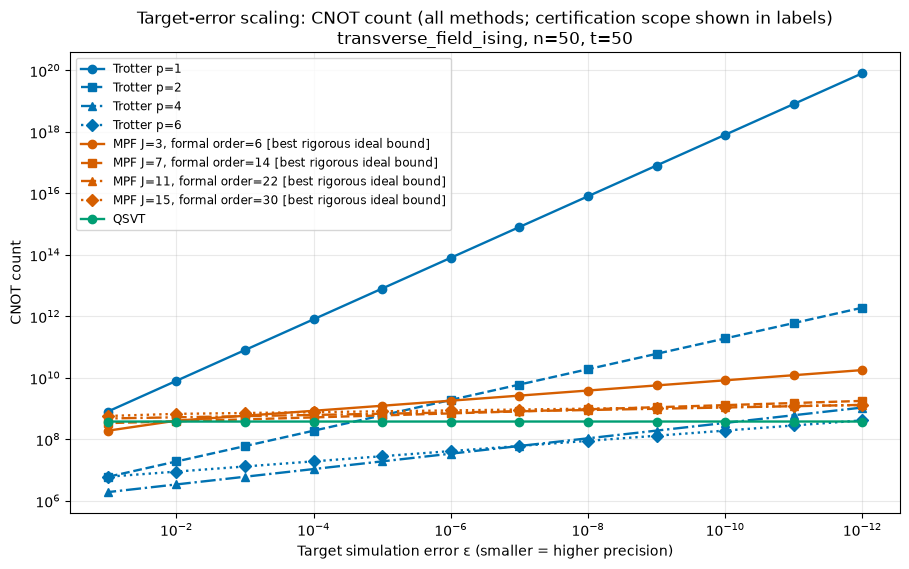

In [24]:
benchmark_config_ising = BenchmarkConfig(
    hamiltonian=HamiltonianSpec(
        model="transverse_field_ising",
        parameters={"coupling": 1.0, "field": 3.0},
    ),
    system_sizes=SYSTEM_SIZES,
    target_errors=TARGET_ERRORS,
    time=TimeScaling("proportional", TIME_PER_QUBIT),
    fixed_system_size=FIXED_SYSTEM_SIZE,
    fixed_target_error=FIXED_TARGET_ERROR,
    methods=[
        *(TrotterMethod(order) for order in (1, 2, 4, 6)),
        *(
            MultiproductMethod(
                terms, error_method = "best-rigorous-ideal"
            )
            for terms in (3, 7, 11, 15)
        ),
        QSVTMethod(),
    ],
)

benchmark_data_ising = run_benchmark(benchmark_config_ising, show_progress=True)
benchmark_data_ising[[
    "sweep", "system_qubits", "evolution_time", "target_error",
    "method_label", "bound_method", "bound_rigorous", "bound_scope",
    "bound_target_satisfied", "circuit_bound_scope",
    "circuit_bound_rigorous", "circuit_target_satisfied",
    "t_count", "cnot_count", "status",
]].head(16)

detailed_figures_ising = (
    plot_benchmark(benchmark_data_ising, sweep="system-size", metric="t_count"),
    plot_benchmark(benchmark_data_ising, sweep="system-size", metric="cnot_count"),
    plot_benchmark(benchmark_data_ising, sweep="target-error", metric="t_count"),
    plot_benchmark(benchmark_data_ising, sweep="target-error", metric="cnot_count"),
)

#### 簡易版（各点でT count最小の次数）

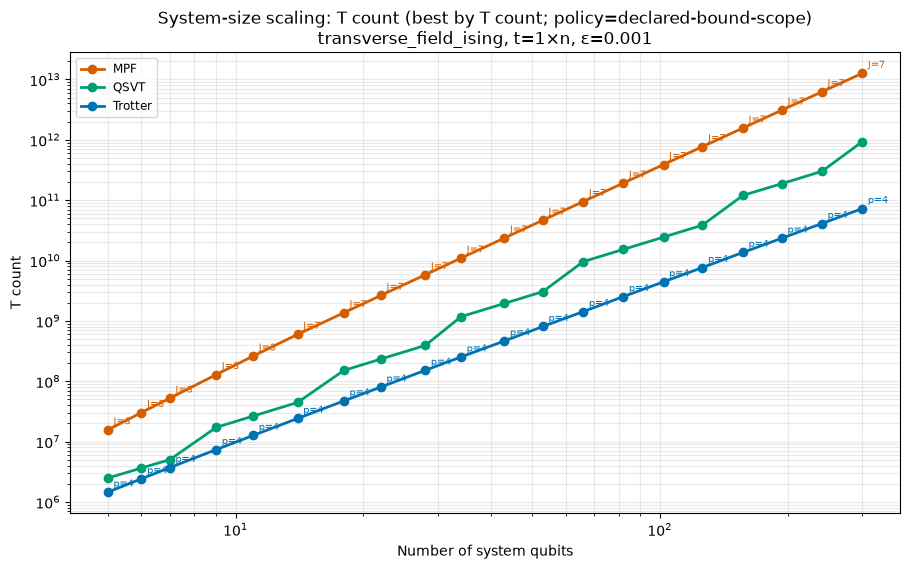

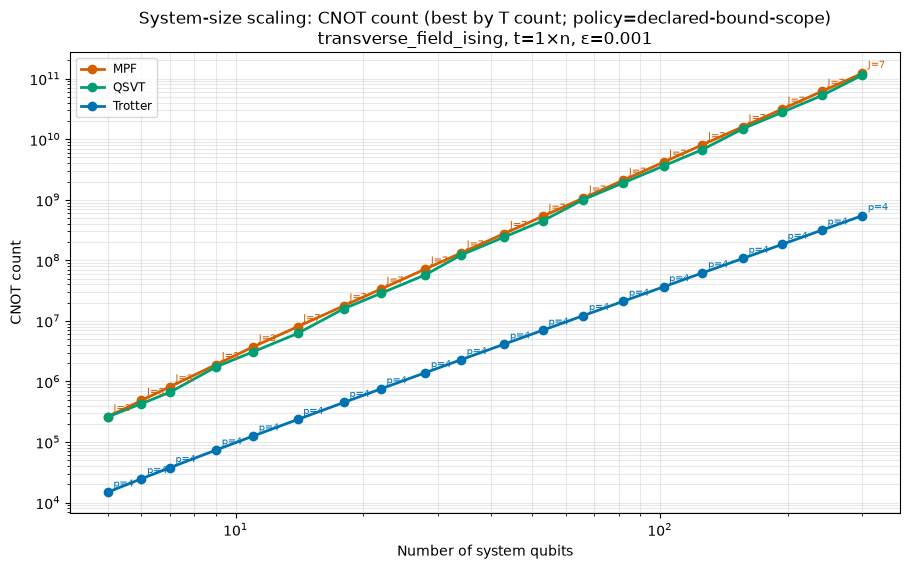

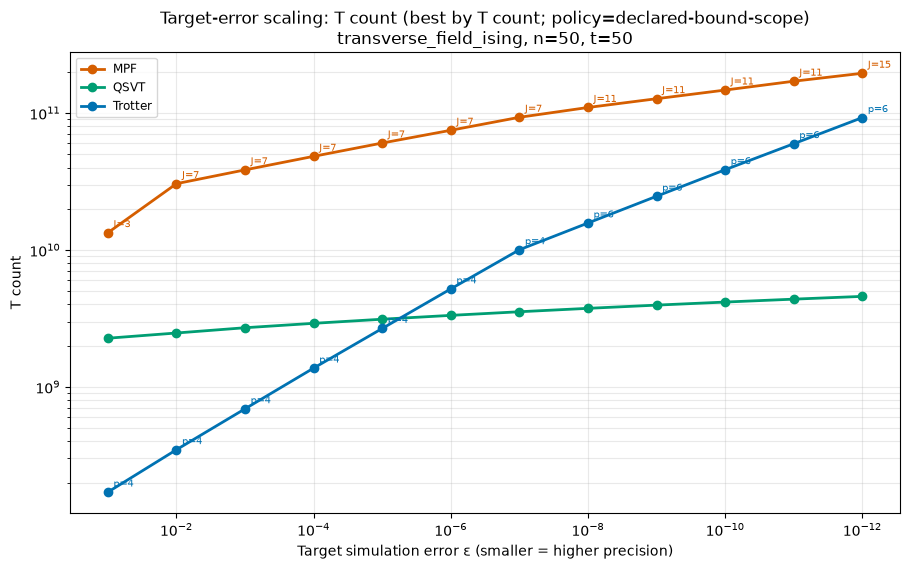

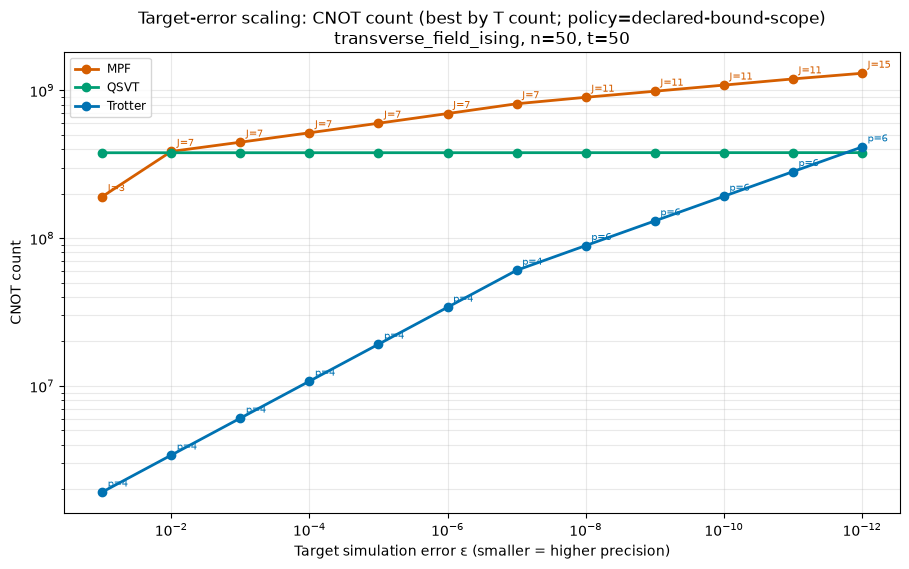

: 

In [ ]:
def simple_benchmark_figures(data):
    return tuple(
        plot_benchmark(
            data,
            sweep=sweep,
            metric=metric,
            summary=True,
            selection_metric="t_count",
            certification_policy="declared-bound-scope",
        )
        for sweep in ("system-size", "target-error")
        for metric in ("t_count", "cnot_count")
    )


simple_figures_ising = simple_benchmark_figures(benchmark_data_ising)

### Heisenberg chain の比較

#### 詳細版（全次数）

In [ ]:
benchmark_config_heisenberg = BenchmarkConfig(
    hamiltonian=HamiltonianSpec(
        model="heisenberg_chain",
        parameters={"coupling": 1.0, "field_z": 0.3},
    ),
    system_sizes=SYSTEM_SIZES,
    target_errors=TARGET_ERRORS,
    time=TimeScaling("proportional", TIME_PER_QUBIT),
    fixed_system_size=FIXED_SYSTEM_SIZE,
    fixed_target_error=FIXED_TARGET_ERROR,
    methods=[
        *(TrotterMethod(order) for order in (1, 2, 4, 6)),
        *(
            MultiproductMethod(
                terms, error_method = "best-rigorous-ideal"
            )
            for terms in (3, 7, 11, 15)
        ),
        QSVTMethod(),
    ],
)

benchmark_data_heisenberg = run_benchmark(benchmark_config_heisenberg, show_progress=True)
benchmark_data_heisenberg[[
    "sweep", "system_qubits", "evolution_time", "target_error",
    "method_label", "bound_method", "bound_rigorous", "bound_scope",
    "bound_target_satisfied", "circuit_bound_scope",
    "circuit_bound_rigorous", "circuit_target_satisfied",
    "t_count", "cnot_count", "status",
]].head(16)

detailed_figures_heisenberg = (
    plot_benchmark(benchmark_data_heisenberg, sweep="system-size", metric="t_count"),
    plot_benchmark(benchmark_data_heisenberg, sweep="system-size", metric="cnot_count"),
    plot_benchmark(benchmark_data_heisenberg, sweep="target-error", metric="t_count"),
    plot_benchmark(benchmark_data_heisenberg, sweep="target-error", metric="cnot_count"),
)

benchmark:  57%|█████▋    | 165/288 [1:06:10<2:32:40, 74.47s/it, system-size n=241 eps=0.001 trotter-p4 ok]                  

#### 簡易版（各点でT count最小の次数）

In [ ]:
simple_figures_heisenberg = simple_benchmark_figures(benchmark_data_heisenberg)

## 4. 必要な場合だけ保存

Python APIは既定では何も保存しません。結果を残す場合だけ次のセルのコメントを外してください。実行ごとに新しいrun directoryが作られ、以前の結果は上書きされません。

In [ ]:
print(benchmark_config_ising)
print(benchmark_data_ising)

In [ ]:
print(benchmark_config_heisenberg)
print(benchmark_data_heisenberg)

In [ ]:
# run_directory, csv_path, metadata_path = save_benchmark(
#     benchmark_data_ising, benchmark_config_ising, output_root="../benchmark_outputs"
# )
# run_directory

### 解釈上の注意

- QSVT の PREPARE/SELECT コストは Hamiltonian の入力モデルに強く依存します。ここでは一般の Pauli-LCU を公平に数えています。
- 8構成とも同じbackend非依存planから得た解析回路コストの比較です。planは論理演算だけを保持し、temporary-AND、分解後のrotation/CNOT、work qubitは構造化解析backendがprovenance付きで計算します。MPF と QSVT の解析値は segment / 回路ごとの 3-step robust OAA を含みます。success probabilityは初期状態とpostselectionに依存する観測量なので、解析benchmarkの`nominal_success_probability`は空欄です。
- Trotter次数1, 2はChilds交換子上界、次数4, 6はgroup数がwork cap内ならSchubert--Mendl交換子上界を使います。fallbackはCSVの`bound_method`と`bound_rigorous`で明示されます。proxy selectorはresourceを選択できますが、idealまたは実装回路のcertificationにはなりません。
- MPFは既定でLow–Kliuchnikov–Wiebe Eq. (14)--(16)の`low2019-l1-ideal-rigorous` selectorを使い、そのglobal claimはideal MPF operatorを対象にします。one-segment OAA good blockとは別に、Gilyén–Su–Low–Wiebeのblock-encoding積の上界が適用できるときは、実装するrepeated shared-ancilla projected good blockにも保守的なrigorous claimがあります。ただし`circuit_target_satisfied`はその上界が実際に予算内の場合だけtrueであり、full joint unitaryや正規化後のpostselected stateをcertifyしません。
- QSVTの次数selectorは既存のJacobi–Anger parity-tail条件のままです。exact scaled polynomialとideal OAA algebraにはscope付きclaimがありますが、pyQSPのfloating-point phase reconstructionと構築回路の一様誤差は未certifiedです。そのためQSVTの`circuit_bound_rigorous`と`circuit_target_satisfied`はfalseです。grid上のphase residualはcalibration observationとしてのみ扱います。
- 解析モデルの controlled QSVT は、`V`/`V^dagger` が block-encoding query を共有し projector 位相のみ選択する効率的コンパイルを仮定します。
- $t(n)=n$ は伝播速度を厳密に推定したものではなく、局所相互作用が系全体へ広がる時間をサイズに比例させる比較規約です。
- family summaryの既定policyは実装回路scopeの`circuit_target_satisfied`を使います。宣言scopeを明示的に選んだ場合だけ`bound_target_satisfied`を使い、`legacy-w2-proxy` rowはfull plotではheuristic表示され、summaryから除外されます。
- 永続benchmark schemaはこの段階では2.0のままです。flatな`bound_*`/`circuit_*`列は保守的な互換viewであり、単一点reportの構造化`error_analysis`がin-memory semanticsの正本です。